___
<img style="float: right; margin: 15px 15px 15px 15px;" src="https://sodal.cl/wp-content/uploads/2024/08/caracteristicas-aluminio-600x375.jpg" width="380px" height="200px" />


# <font color= #bbc28d> **Sistema Híbrido de Predicción y Gestión de Riesgo (FNN + GARCH)** </font>
#### <font color= #2E9AFE> `Examen 2 - MNLP`</font>
- <Strong> Diana Valdivia, Daniela de la Torre, Aissa Gonzáles & Rafael Takata. </Strong>
- <Strong> Fecha </Strong>: 12/04/2026.

___

<p style="text-align:right;"> Image retrieved from: https://sodal.cl/wp-content/uploads/2024/08/caracteristicas-aluminio-600x375.jpg</p>

El activo elegido para este estudio es el aluminio, un commodity industrial de gran relevancia por su amplia utilización en sectores como la construcción, el transporte, el empaque y la manufactura. Su precio está influenciado por factores como la oferta global, la demanda industrial, los costos energéticos y las condiciones macroeconómicas, lo que lo convierte en un activo interesante para analizar desde una perspectiva financiera y de riesgo. Además, al tratarse de un commodity con variaciones frecuentes en su precio, representa un buen caso de estudio para aplicar modelos predictivos y de volatilidad. La motivación principal de este trabajo es mostrar cómo un Hedge Fund podría usar herramientas FFNN y GARCH para apoyar sus decisiones de inversión.

In [60]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import acf, pacf
from scipy import stats
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# Renderizado HTML en Jupyter / VS Code
pio.renderers.default = "notebook"
#pio.renderers.default = "colab"

In [25]:
datos = pd.read_csv(r"Aluminium Historical Data.csv")
datos = datos[['Date', 'Price']].copy()

datos['Date'] = pd.to_datetime(datos['Date'], format='mixed')
datos['Price'] = datos['Price'].str.replace(',', '').astype(float)

datos = datos.sort_values('Date')

fig = px.line(datos, x='Date', y='Price', title='Precio del Aluminio')
fig.show()

In [26]:
# Parsear fecha y ordenar cronológicamente
datos = datos.sort_values('Date').reset_index(drop=True)
datos.set_index('Date', inplace=True)

print("=" * 55)
print("  RESUMEN GENERAL DEL DATASET")
print("=" * 55)
print(f"  Periodo     : {datos.index.min().date()} → {datos.index.max().date()}")
print(f"  Observaciones: {len(datos):,}")
print(f"  Frecuencia aprox.: {pd.infer_freq(datos.index) or 'irregular (ver gaps)'}")

# Valores nulos
nulos = datos.isnull().sum()
print(f"  Valores nulos: {nulos.values[0]}")

  RESUMEN GENERAL DEL DATASET
  Periodo     : 2022-01-10 → 2026-04-02
  Observaciones: 1,070
  Frecuencia aprox.: irregular (ver gaps)
  Valores nulos: 0


In [27]:
fechas_completas = pd.date_range(datos.index.min(), datos.index.max())
faltantes = fechas_completas.difference(datos.index)

print(len(faltantes))
print(faltantes[:10])

474
DatetimeIndex(['2022-01-15', '2022-01-16', '2022-01-22', '2022-01-23',
               '2022-01-29', '2022-01-30', '2022-02-05', '2022-02-06',
               '2022-02-12', '2022-02-13'],
              dtype='datetime64[ns]', freq=None)


In [28]:
# Rellenamos business days faltantes
datos = datos.asfreq('B').ffill()

fechas_completas = pd.date_range(datos.index.min(),datos.index.max(),freq='B')
faltantes = fechas_completas.difference(datos.index)

print(len(faltantes))

0


# **<font color= #bbc28d> GARCH </font>**
El modelo **GARCH (Generalized Autoregressive Conditional Heteroskedasticity)** es una técnica utilizada para modelar y predecir la **volatilidad** en series de tiempo financieras, como precios de commodities, acciones o divisas.

A diferencia de modelos tradicionales que asumen varianza constante, GARCH permite que la **varianza cambie en el tiempo**, lo cual es más realista para datos financieros donde existen periodos de alta y baja volatilidad.

### **Idea principal**
- Los retornos financieros suelen mostrar **clustering de volatilidad**
- Periodos con alta volatilidad tienden a ser seguidos por alta volatilidad
- Periodos tranquilos tienden a permanecer tranquilos

GARCH modela este comportamiento haciendo que la varianza dependa de:
1. Errores pasados (shocks recientes)
2. Varianza pasada (persistencia)

### **¿Por qué usarlo en el precio del aluminio?**
El precio del aluminio, como otros commodities, presenta:
- Periodos de alta volatilidad
- Eventos macroeconómicos
- Choques de oferta y demanda

GARCH permite capturar estos cambios dinámicos en la volatilidad y generar predicciones más realistas.



## **<font color= #bbc28d> &ensp; • Obtenemos datos y gráficas de serie de tiempo </font>**
Obtenemos la serie de tiempo del sitio web ìnvesting.com` para graficar. Se calcula los rendimientos logarítmicos porcentuales, los cuales se representan como:$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) \times 100$$

Usualmente se usan retorno logaritmico porque en escalas pequeñas su compertamiento es muy similar al del retorno "normal" y al ser logaritmo, el comportamiento sigue una distribución más estable.

In [ ]:
# Calculamos los retornos logarítmicos porcentuales usando 'Close'
returns = 100 * np.log(datos['Price'] / datos['Price'].shift(1)).dropna()

# Gráfica de la serie de retornos usando Plotly
fig = go.Figure()
fig.add_trace(go.Scatter(x=returns.index, y=returns.squeeze(), mode='lines', name='Retornos MAL3'))
fig.update_layout(title=f'Retornos Diarios del Aluminio',
                  yaxis_title='Retornos (%)')
fig.show()

## **<font color= #bbc28d> &ensp; • Selección y validación de modelo. </font>**

Para justificar si es estadísticamente viable utilizar un modelo GARCH, se calculan las graficas ACF y PACF; pero utilizando los retornos al cuadrado.

**Retornos al Cuadrado**

Las gráficas ACF y PACF miden la autocorrelación (qué tanto se parece el dato de hoy vs los datos del pasado)
- ACF/PACF de los Retornos al Cuadrado ($r_t^2$)
  - ¿Qué miden? ->
    Dependencia no lineal en el segundo momento estadístico (la varianza/volatilidad). Al elevar al cuadrado, eliminamos el signo (positivo o negativo) y nos quedamos solo con la magnitud del movimiento.
  - ¿Qué pregunta responden? ->
    Saber que ayer hubo un movimiento violento (sin importar si fue hacia arriba o hacia abajo) me ayuda a predecir si hoy el mercado seguirá turbulento.
  - Lo que verás en la gráfica ->
    Verás múltiples barras que sobresalen de la zona de significancia. Esto demuestra matemáticamente el Volatility Clustering (agrupamiento de volatilidad).

Si la PACF o ACF de retornos al cuadrado no muestra barras significativas, no se recomienda utilizar un modelo GARCH (Puede ser un modelo EGARCH o de otra familia)

In [ ]:
# Retornos al cuadrado
sq_returns = returns**2

# Calcular ACF y PACF
lag_acf = acf(sq_returns, nlags=20)
lag_pacf = pacf(sq_returns, nlags=20, method='ols')

# Graficar ACF y PACF con Plotly
fig = make_subplots(rows=1, cols=2, subplot_titles=('ACF de Retornos al Cuadrado', 'PACF de Retornos al Cuadrado'))

# Añadir barras de ACF
fig.add_trace(go.Bar(x=np.arange(len(lag_acf)), y=lag_acf, name='ACF'), row=1, col=1)
# Añadir barras de PACF
fig.add_trace(go.Bar(x=np.arange(len(lag_pacf)), y=lag_pacf, name='PACF'), row=1, col=2)

# Líneas de significancia (aprox 1.96 / sqrt(N))
sig_level = 1.96 / np.sqrt(len(returns))
for i in [1, 2]:
    fig.add_hline(y=sig_level, line_dash="dash", line_color="red", row=1, col=i)
    fig.add_hline(y=-sig_level, line_dash="dash", line_color="red", row=1, col=i)

fig.update_layout(title='Análisis de Dependencia de Varianza', showlegend=False)
fig.show()

## **<font color= #bbc28d> &ensp; • Modelado </font>**

### **Forma general del modelo GARCH(1,1)**

La varianza condicional se define como:

$
\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2
$

Donde:
- $ \sigma_t^2 $ : varianza condicional en el tiempo t
- $ \omega $ : constante
- $ \alpha $ : efecto de shocks recientes
- $ \beta $ : persistencia de la volatilidad
- $ \varepsilon_{t-1}^2 $ : error cuadrado del periodo anterior

In [ ]:
# Aqui va codigo


# **<font color= #66b0b0> FFNN </font>**
Una **FFNN (Feedforward Neural Network)** es un tipo de red neuronal artificial utilizada para modelar relaciones no lineales entre variables. Se denomina *feedforward* porque la información fluye en una sola dirección: desde la capa de entrada, pasando por capas ocultas, hasta la capa de salida, sin ciclos ni retroalimentación.

Estas redes son especialmente útiles cuando la relación entre variables es compleja y difícil de modelar con técnicas estadísticas tradicionales.

### **¿Para qué se usa en series financieras?**

Las FFNN pueden:

* Capturar relaciones no lineales
* Detectar patrones complejos
* Aprender dinámicas temporales usando *lags*

### **Aplicación al precio del aluminio**

Para el precio del aluminio, una FFNN puede:

* Aprender patrones ocultos en la serie
* Modelar dinámicas no lineales del mercado



In [29]:
# Aqui va codigo
# Usamos el precio de cierre de la acción como entrana
entrada_ffnn = datos['Price'].dropna().values.reshape(-1, 1)

# Tamaños
train_size = int(len(entrada_ffnn) * 0.7)
val_size = int(len(entrada_ffnn) * 0.15)

# Splits
train_data = entrada_ffnn[:train_size]
val_data = entrada_ffnn[train_size:train_size + val_size]
test_data = entrada_ffnn[train_size + val_size:]

print(len(train_data), len(val_data), len(test_data))

772 165 167


In [30]:
# Escalamiento
scaler = MinMaxScaler(feature_range=(0, 1))

# Entrenamos con train
train_scaled = scaler.fit_transform(train_data)

# Solo transformamos con val y test
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

In [49]:
# Crear las ventanas
def crear_ventanas(data, window_size):
    X, y = [], []

    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        y.append(data[i + window_size, 0])

    return np.array(X), np.array(y)

# 5 días atras ( esto es un hiperparámetro)
window_size = 3

X_train, y_train = crear_ventanas(train_scaled, window_size)
X_val, y_val = crear_ventanas(val_scaled, window_size)
X_test, y_test = crear_ventanas(test_scaled, window_size)

## <font color= #66b0b0> &ensp; • **Modelado** </font>
Una red neuronal feedforward se compone de:

* **Capa de entrada**: recibe los datos (por ejemplo, retornos pasados)
* **Capas ocultas**: transforman la información mediante funciones no lineales
* **Capa de salida**: genera la predicción final

Cada neurona aplica la siguiente transformación:

$
y = f\left(\sum_{i=1}^{n} w_i x_i + b \right)
$

Donde:

* $x_i$ : variables de entrada
* $w_i$ : pesos de la red
* $b$ : sesgo (bias)
* $f$ : función de activación (ReLU, tanh, sigmoid, etc.)

In [54]:
# Aqui va codigo
# Modelo FFNN
model = Sequential([
    Dense(64, activation='relu', input_dim=window_size),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)])

model.summary()

model.compile(optimizer=Adam(learning_rate=0.005),loss='mse',metrics=['mae', 'mape'])

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# Entrenar la red
history = model.fit(X_train, y_train, epochs=80, batch_size=16, validation_data=(X_val, y_val))

Epoch 1/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0089 - mae: 0.0542 - mape: 59199.1484 - val_loss: 0.0012 - val_mae: 0.0311 - val_mape: 12.1276
Epoch 2/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011 - mae: 0.0238 - mape: 64485.4141 - val_loss: 5.3459e-04 - val_mae: 0.0191 - val_mape: 7.6649
Epoch 3/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.0287e-04 - mae: 0.0203 - mape: 54391.3047 - val_loss: 2.6243e-04 - val_mae: 0.0128 - val_mape: 5.3221
Epoch 4/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.2134e-04 - mae: 0.0215 - mape: 54697.9609 - val_loss: 0.0011 - val_mae: 0.0308 - val_mape: 12.3005
Epoch 5/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.3574e-04 - mae: 0.0208 - mape: 36348.7227 - val_loss: 4.3687e-04 - val_mae: 0.0172 - val_mape: 7.5108
Epoch 6/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.7600e-04 - mae: 0.0188 - mape: 40317.8398 - val_loss: 3.6132e-04 - val_mae: 0.0152 - val_mape: 6.2751
Epoch 7/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 

El modelo aprende rápidamente en las primeras épocas, reduciendo tanto la pérdida como el error en entrenamiento y validación. Alrededor de la época **8–12**, el modelo se estabiliza: las métricas de validación dejan de mejorar significativamente, aunque no empeoran de forma sostenida, lo que descarta un sobreajuste severo. Los entrenamientos posteriores solo realizan ajustes menores sin beneficios reales.

Esto demuestra que el modelo converge rápidamente y que un número menor de épocas con early stopping sería suficiente para obtener resultados similares pero con menor gasto computacional.

En nuestro caso, debido a los reesultados del modelo no volveremos a re-entrenar con menor número de épocas, pero es algo a considerar en el futuro **"A veces menos es más"**.

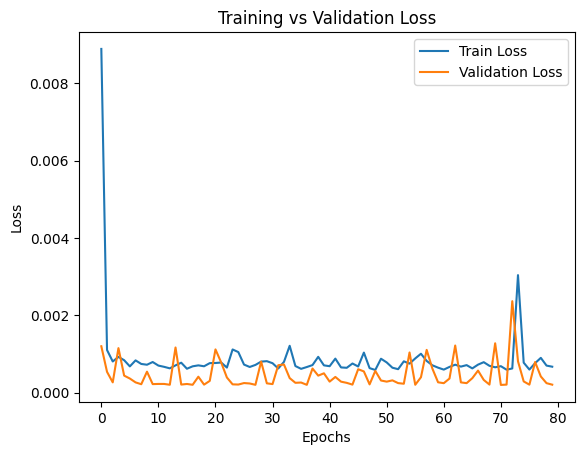

In [56]:
import matplotlib.pyplot as plt

# Graficar epoca vs pérdida
plt.figure()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [57]:
# Predicción
y_pred_scaled = model.predict(X_test, verbose=0)

# Invertir escalamiento
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

# Métricas
mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE: 27.036
RMSE: 38.752


In [68]:
precio_promedio = datos['Price'].mean()
print("Precio promedio del Aluminio:", round(precio_promedio,2))

Precio promedio del Aluminio: 2564.76


Con un precio promedio de **2564.76 USD**, el modelo presenta un MAE de **27.04** USD y un RMSE de **38.75** USD, lo que equivale aproximadamente a un error medio del **1.05%** respecto al nivel promedio de la serie.

Esto indica que, en promedio, las predicciones del modelo se desvían alrededor de ±27 USD del valor real, mientras que los errores más grandes se sitúan cerca de 39 USD.

Considerando la magnitud del precio del activo, estos errores son relativamente bajos y sugieren que el modelo captura adecuadamente la dinámica general de la serie temporal,

In [59]:
# donde empieza el test en la serie original
test_start = train_size + val_size

# offset por las ventanas
offset = window_size

# índice alineado
test_index = datos.index[test_start + offset:]

# histórico hasta antes del test predicho
historico_index = datos.index[:test_start + offset]
historico_values = datos['Price'][:test_start + offset]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=historico_index,
    y=historico_values,
    name="Histórico"
))

fig.add_trace(go.Scatter(
    x=test_index,
    y=y_test_real.flatten(),
    name="Test Real"
))

fig.add_trace(go.Scatter(
    x=test_index,
    y=y_pred.flatten(),
    name="Predicción"
))

fig.update_layout(title="FFNN - Histórico vs Predicción")
fig.show()

In [62]:
# Guardar modelo entero
model.save("modelo_ffnn.keras")

# Guardar pesos
model.save_weights("pesos_ffnn.weights.h5")

# Guardar el scaler utilizado
joblib.dump(scaler, "scaler_ffnn.pkl")

['scaler_ffnn.pkl']